In [336]:
# Cell 1 - Import library

from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

print("Libraries loaded.")

Libraries loaded.


In [ ]:
# Cell 2 - Konfigurasi file dan parameter audit

# ============================================================
# FILE PAIR CONFIG
# ============================================================

# FILE_A = Path("/media/spell/Spell-lab/Lidar/A.Raw Dataset/Bungkuk/Lina/CSV/9.Csv")
# FILE_B = Path("/media/spell/Spell-lab/Lidar/A.Raw Dataset/Bungkuk/Lina/CSV/7.Csv")

# FILE_A = Path("/media/spell/Spell-lab/Lidar/Z.Trial Error/adel/1.Csv")
# FILE_B = Path("/media/spell/Spell-lab/Lidar/Z.Trial Error/adel/2.Csv")

FILE_A = Path("/media/spell/Spell-lab/Lidar/A.Raw_Testing/Controlled Room/Bungkuk/Kanaya/CSV/1.Csv")
FILE_B = Path("/media/spell/Spell-lab/Lidar/A.Raw_Testing/Controlled Room/Bungkuk/Kanaya/CSV/2.Csv")

LABEL_A = "A_1csv"
LABEL_B = "B_2csv"

# ============================================================
# TIMESTAMP / FRAME CONFIG
# ============================================================

TIMESTAMP_UNIT = "ns"      # ns, us, ms, s
FRAME_DURATION_MS = 100    # absolute-time frame, 100 ms

USE_SORT_TIMESTAMP = True  # True: sort by Timestamp, False: original row order

# ============================================================
# ROI CONFIG, ORIGINAL COORDINATES ONLY
# ============================================================

ROI_X_MIN, ROI_X_MAX = 0.0, 3.0
ROI_Y_MIN, ROI_Y_MAX = -1.5, 1.5
ROI_Z_MIN, ROI_Z_MAX = 0.0, 2.0

# ============================================================
# SEGMENT CONFIG
# Sesuaikan kalau hasil visual kamu berubah.
# Berdasarkan temuan kamu: B frame 0-46 diduga residual, 47 dst valid.
# ============================================================

B_SUSPECT_START = 0
B_SUSPECT_END = 46

B_VALID_START = 47
B_VALID_END = None  # None berarti sampai akhir

A_HEAD_START = 0
A_HEAD_END = 46

A_TAIL_N_FRAMES = 47

# ============================================================
# HASH / ROUNDING CONFIG
# Untuk cek row overlap. Round XYZ agar tidak gagal karena precision kecil.
# ============================================================

ROUND_DECIMALS_XYZ = 6

print("===== CONFIG =====")
print(f"FILE_A exists: {FILE_A.exists()} | {FILE_A}")
print(f"FILE_B exists: {FILE_B.exists()} | {FILE_B}")
print(f"TIMESTAMP_UNIT: {TIMESTAMP_UNIT}")
print(f"FRAME_DURATION_MS: {FRAME_DURATION_MS}")
print(f"USE_SORT_TIMESTAMP: {USE_SORT_TIMESTAMP}")
print(f"ROI X: {ROI_X_MIN} to {ROI_X_MAX}")
print(f"ROI Y: {ROI_Y_MIN} to {ROI_Y_MAX}")
print(f"ROI Z: {ROI_Z_MIN} to {ROI_Z_MAX}")

===== CONFIG =====
FILE_A exists: True | /media/spell/Spell-lab/Lidar/A.Raw_Testing/Controlled Room/Bungkuk/Kanaya/CSV/1.Csv
FILE_B exists: True | /media/spell/Spell-lab/Lidar/A.Raw_Testing/Controlled Room/Bungkuk/Kanaya/CSV/2.Csv
TIMESTAMP_UNIT: ns
FRAME_DURATION_MS: 100
USE_SORT_TIMESTAMP: True
ROI X: 0.0 to 3.0
ROI Y: -1.5 to 1.5
ROI Z: 0.0 to 2.0


In [338]:
# Cell 3 - Fungsi load dan validasi Clean Dataset

REQUIRED_COLUMNS = ["Timestamp", "X", "Y", "Z", "Reflectivity"]

def load_clean_csv(path: Path, label: str) -> pd.DataFrame:
    if not path.exists():
        raise FileNotFoundError(f"File not found: {path}")

    df = pd.read_csv(path)

    missing_cols = [c for c in REQUIRED_COLUMNS if c not in df.columns]
    if missing_cols:
        raise ValueError(f"{label} missing required columns: {missing_cols}")

    df = df[REQUIRED_COLUMNS].copy()
    df["_orig_row_id"] = np.arange(len(df), dtype=np.int64)

    for col in REQUIRED_COLUMNS:
        df[col] = pd.to_numeric(df[col], errors="coerce")

    before = len(df)
    df = df.dropna(subset=REQUIRED_COLUMNS).copy()
    after = len(df)

    if USE_SORT_TIMESTAMP:
        df = df.sort_values(["Timestamp", "_orig_row_id"]).reset_index(drop=True)
    else:
        df = df.sort_values("_orig_row_id").reset_index(drop=True)

    print(f"===== LOAD {label} =====")
    print(f"Path              : {path}")
    print(f"Rows before drop  : {before:,}")
    print(f"Rows after drop   : {after:,}")
    print(f"Dropped rows      : {before - after:,}")
    print(f"Unique timestamp  : {df['Timestamp'].nunique():,}")
    print(f"Timestamp min     : {df['Timestamp'].min()}")
    print(f"Timestamp max     : {df['Timestamp'].max()}")
    print()

    return df

df_a = load_clean_csv(FILE_A, LABEL_A)
df_b = load_clean_csv(FILE_B, LABEL_B)

display(df_a.head())
display(df_b.head())

/tmp/ipykernel_98937/4105425917.py:9: DtypeWarning: Columns (0) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(path)


===== LOAD A_1csv =====
Path              : /media/spell/Spell-lab/Lidar/A.Raw_Testing/Controlled Room/Bungkuk/Kanaya/CSV/1.Csv
Rows before drop  : 1,083,745
Rows after drop   : 1,083,744
Dropped rows      : 1
Unique timestamp  : 11,289
Timestamp min     : 2829382432940
Timestamp max     : 2834802292940



/tmp/ipykernel_98937/4105425917.py:9: DtypeWarning: Columns (0) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(path)


===== LOAD B_2csv =====
Path              : /media/spell/Spell-lab/Lidar/A.Raw_Testing/Controlled Room/Bungkuk/Kanaya/CSV/2.Csv
Rows before drop  : 1,178,305
Rows after drop   : 1,178,304
Dropped rows      : 1
Unique timestamp  : 12,274
Timestamp min     : 2844392752940
Timestamp max     : 2850284152940



,Timestamp,X,Y,Z,Reflectivity,_orig_row_id
0,2829382432940,0.304,-1.900,1.820,54.0,1
1,2829382432940,0.255,-1.898,1.767,63.0,2
2,2829382432940,0.211,-1.888,1.701,3.0,3
3,2829382432940,0.163,-1.878,1.648,57.0,4
4,2829382432940,0.347,-1.905,1.834,63.0,5


,Timestamp,X,Y,Z,Reflectivity,_orig_row_id
0,2844392752940,-2.488,-0.352,1.354,81.0,1
1,2844392752940,-2.414,-0.279,1.393,90.0,2
2,2844392752940,-2.344,-0.200,1.430,94.0,3
3,2844392752940,-2.270,-0.122,1.468,111.0,4
4,2844392752940,-2.485,-0.411,1.357,95.0,5


In [339]:
# Cell 4 - Metadata dasar dan points per timestamp

def file_basic_summary(df: pd.DataFrame, label: str) -> dict:
    pts_per_ts = df.groupby("Timestamp").size()

    return {
        "label": label,
        "n_rows": len(df),
        "n_unique_timestamp": df["Timestamp"].nunique(),
        "timestamp_min": df["Timestamp"].min(),
        "timestamp_max": df["Timestamp"].max(),
        "duration_timestamp": df["Timestamp"].max() - df["Timestamp"].min(),
        "points_per_timestamp_min": int(pts_per_ts.min()) if len(pts_per_ts) else np.nan,
        "points_per_timestamp_max": int(pts_per_ts.max()) if len(pts_per_ts) else np.nan,
        "points_per_timestamp_mode": int(pts_per_ts.mode().iloc[0]) if len(pts_per_ts.mode()) else np.nan,
        "x_min": df["X"].min(),
        "x_max": df["X"].max(),
        "y_min": df["Y"].min(),
        "y_max": df["Y"].max(),
        "z_min": df["Z"].min(),
        "z_max": df["Z"].max(),
    }

summary_basic = pd.DataFrame([
    file_basic_summary(df_a, LABEL_A),
    file_basic_summary(df_b, LABEL_B),
])

print("===== BASIC FILE SUMMARY =====")
display(summary_basic)

print("===== POINTS PER TIMESTAMP VALUE COUNTS - FILE A =====")
display(
    df_a.groupby("Timestamp").size()
    .value_counts()
    .reset_index()
    .rename(columns={"index": "points_per_timestamp", 0: "count"})
    .head(20)
)

print("===== POINTS PER TIMESTAMP VALUE COUNTS - FILE B =====")
display(
    df_b.groupby("Timestamp").size()
    .value_counts()
    .reset_index()
    .rename(columns={"index": "points_per_timestamp", 0: "count"})
    .head(20)
)

===== BASIC FILE SUMMARY =====


,label,n_rows,n_unique_timestamp,timestamp_min,timestamp_max,duration_timestamp,points_per_timestamp_min,points_per_timestamp_max,points_per_timestamp_mode,x_min,x_max,y_min,y_max,z_min,z_max
0,A_1csv,1083744,11289,2829382432940,2834802292940,5419860000,96,96,96,-7.510000,3.537,-2.049,12.522000,-1.265,3.886
1,B_2csv,1178304,12274,2844392752940,2850284152940,5891400000,96,96,96,-7.525001,3.580,-2.035,12.478001,-1.270,3.886


===== POINTS PER TIMESTAMP VALUE COUNTS - FILE A =====


,points_per_timestamp,count
0,96,11289


===== POINTS PER TIMESTAMP VALUE COUNTS - FILE B =====


,points_per_timestamp,count
0,96,12274


In [340]:
# Cell 5 - Timestamp overlap antara dua file

ts_a = set(df_a["Timestamp"].dropna().unique())
ts_b = set(df_b["Timestamp"].dropna().unique())

ts_intersection = ts_a.intersection(ts_b)

timestamp_overlap_summary = {
    "unique_timestamp_A": len(ts_a),
    "unique_timestamp_B": len(ts_b),
    "overlap_timestamp": len(ts_intersection),
    "overlap_ratio_A": len(ts_intersection) / len(ts_a) if len(ts_a) else 0,
    "overlap_ratio_B": len(ts_intersection) / len(ts_b) if len(ts_b) else 0,
}

print("===== TIMESTAMP OVERLAP SUMMARY =====")
display(pd.DataFrame([timestamp_overlap_summary]).T.rename(columns={0: "value"}))

if len(ts_intersection) > 0:
    overlap_ts_sample = sorted(list(ts_intersection))[:20]
    print("Sample overlap timestamps:")
    print(overlap_ts_sample)
else:
    print("No overlapping timestamps found.")

===== TIMESTAMP OVERLAP SUMMARY =====


,value
unique_timestamp_A,11289.0
unique_timestamp_B,12274.0
overlap_timestamp,0.0
overlap_ratio_A,0.0
overlap_ratio_B,0.0


No overlapping timestamps found.


In [341]:
# Cell 6 - Identical row overlap

def make_row_hash(df: pd.DataFrame, round_decimals: int = 6) -> pd.Series:
    temp = df[["Timestamp", "X", "Y", "Z", "Reflectivity"]].copy()

    temp["X"] = temp["X"].round(round_decimals)
    temp["Y"] = temp["Y"].round(round_decimals)
    temp["Z"] = temp["Z"].round(round_decimals)
    temp["Reflectivity"] = temp["Reflectivity"].round(round_decimals)

    return pd.util.hash_pandas_object(temp, index=False)

hash_a = make_row_hash(df_a, ROUND_DECIMALS_XYZ)
hash_b = make_row_hash(df_b, ROUND_DECIMALS_XYZ)

set_hash_a = set(hash_a.values)
set_hash_b = set(hash_b.values)

row_hash_intersection = set_hash_a.intersection(set_hash_b)

row_overlap_summary = {
    "unique_row_hash_A": len(set_hash_a),
    "unique_row_hash_B": len(set_hash_b),
    "identical_unique_row_hash": len(row_hash_intersection),
    "identical_ratio_A": len(row_hash_intersection) / len(set_hash_a) if len(set_hash_a) else 0,
    "identical_ratio_B": len(row_hash_intersection) / len(set_hash_b) if len(set_hash_b) else 0,
    "round_decimals_xyz": ROUND_DECIMALS_XYZ,
}

print("===== IDENTICAL ROW OVERLAP SUMMARY =====")
display(pd.DataFrame([row_overlap_summary]).T.rename(columns={0: "value"}))

===== IDENTICAL ROW OVERLAP SUMMARY =====


,value
unique_row_hash_A,1067393.0
unique_row_hash_B,1134258.0
identical_unique_row_hash,0.0
identical_ratio_A,0.0
identical_ratio_B,0.0
round_decimals_xyz,6.0


In [342]:
# Cell 7 - Buat temp_frame_id berbasis absolute time

def get_frame_duration_timestamp(frame_duration_ms: int, timestamp_unit: str):
    if timestamp_unit == "ns":
        return int(frame_duration_ms * 1_000_000)
    if timestamp_unit == "us":
        return int(frame_duration_ms * 1_000)
    if timestamp_unit == "ms":
        return int(frame_duration_ms)
    if timestamp_unit == "s":
        return frame_duration_ms / 1000.0
    raise ValueError("TIMESTAMP_UNIT must be one of: ns, us, ms, s")

FRAME_DURATION_TS = get_frame_duration_timestamp(FRAME_DURATION_MS, TIMESTAMP_UNIT)

def assign_absolute_time_frame(df: pd.DataFrame, label: str) -> pd.DataFrame:
    out = df.copy()
    t0 = out["Timestamp"].min()

    out["temp_frame_id"] = ((out["Timestamp"] - t0) // FRAME_DURATION_TS).astype(int)

    print(f"===== ABSOLUTE TIME FRAME - {label} =====")
    print(f"Timestamp start    : {t0}")
    print(f"Frame duration ts  : {FRAME_DURATION_TS}")
    print(f"Temp frames        : {out['temp_frame_id'].nunique():,}")
    print(f"Temp frame min/max : {out['temp_frame_id'].min()} to {out['temp_frame_id'].max()}")
    print()

    return out

df_a_frame = assign_absolute_time_frame(df_a, LABEL_A)
df_b_frame = assign_absolute_time_frame(df_b, LABEL_B)

===== ABSOLUTE TIME FRAME - A_1csv =====
Timestamp start    : 2829382432940
Frame duration ts  : 100000000
Temp frames        : 55
Temp frame min/max : 0 to 54

===== ABSOLUTE TIME FRAME - B_2csv =====
Timestamp start    : 2844392752940
Frame duration ts  : 100000000
Temp frames        : 59
Temp frame min/max : 0 to 58



In [343]:
# Cell 8 - ROI-only filtering

def apply_roi_only(df: pd.DataFrame, label: str) -> pd.DataFrame:
    roi_mask = (
        (df["X"] >= ROI_X_MIN) & (df["X"] <= ROI_X_MAX) &
        (df["Y"] >= ROI_Y_MIN) & (df["Y"] <= ROI_Y_MAX) &
        (df["Z"] >= ROI_Z_MIN) & (df["Z"] <= ROI_Z_MAX)
    )

    roi_df = df.loc[roi_mask].copy()

    print(f"===== ROI ONLY - {label} =====")
    print(f"Rows before ROI : {len(df):,}")
    print(f"Rows after ROI  : {len(roi_df):,}")
    print(f"Retained ratio  : {len(roi_df) / len(df):.6f}" if len(df) else "Retained ratio: NA")
    print(f"ROI frames      : {roi_df['temp_frame_id'].nunique():,}")
    print()

    return roi_df

df_a_roi = apply_roi_only(df_a_frame, LABEL_A)
df_b_roi = apply_roi_only(df_b_frame, LABEL_B)

display(df_a_roi.head())
display(df_b_roi.head())

===== ROI ONLY - A_1csv =====
Rows before ROI : 1,083,744
Rows after ROI  : 124,005
Retained ratio  : 0.114423
ROI frames      : 55

===== ROI ONLY - B_2csv =====
Rows before ROI : 1,178,304
Rows after ROI  : 119,153
Retained ratio  : 0.101122
ROI frames      : 59



,Timestamp,X,Y,Z,Reflectivity,_orig_row_id,temp_frame_id
211,2829383392940,2.519,-0.633,1.973,22.0,212,0
215,2829383392940,2.521,-0.571,1.962,99.0,216,0
219,2829383392940,2.523,-0.509,1.951,91.0,220,0
223,2829383392940,2.536,-0.449,1.950,91.0,224,0
227,2829383392940,2.536,-0.387,1.940,93.0,228,0


,Timestamp,X,Y,Z,Reflectivity,_orig_row_id,temp_frame_id
400,2844394672940,0.0,0.0,0.0,50.0,401,0
407,2844394672940,0.0,0.0,0.0,50.0,408,0
416,2844394672940,0.0,0.0,0.0,50.0,417,0
423,2844394672940,0.0,0.0,0.0,50.0,424,0
432,2844394672940,0.0,0.0,0.0,50.0,433,0


In [344]:
# Cell 9 - Fingerprint per frame ROI

def build_frame_fingerprint(df_roi: pd.DataFrame, label: str) -> pd.DataFrame:
    if len(df_roi) == 0:
        raise ValueError(f"{label}: ROI dataframe is empty.")

    fp = (
        df_roi.groupby("temp_frame_id")
        .agg(
            n_points=("temp_frame_id", "size"),
            timestamp_min=("Timestamp", "min"),
            timestamp_max=("Timestamp", "max"),

            x_med=("X", "median"),
            y_med=("Y", "median"),
            z_med=("Z", "median"),

            x_mean=("X", "mean"),
            y_mean=("Y", "mean"),
            z_mean=("Z", "mean"),

            x_std=("X", "std"),
            y_std=("Y", "std"),
            z_std=("Z", "std"),

            x_min=("X", "min"),
            x_max=("X", "max"),
            y_min=("Y", "min"),
            y_max=("Y", "max"),
            z_min=("Z", "min"),
            z_max=("Z", "max"),

            reflectivity_mean=("Reflectivity", "mean"),
            reflectivity_med=("Reflectivity", "median"),
        )
        .reset_index()
        .sort_values("temp_frame_id")
        .reset_index(drop=True)
    )

    fp["x_range"] = fp["x_max"] - fp["x_min"]
    fp["y_range"] = fp["y_max"] - fp["y_min"]
    fp["z_range"] = fp["z_max"] - fp["z_min"]

    fp["dx"] = fp["x_med"].diff()
    fp["dy"] = fp["y_med"].diff()
    fp["dz"] = fp["z_med"].diff()
    fp["dxyz"] = np.sqrt(fp["dx"]**2 + fp["dy"]**2 + fp["dz"]**2)

    fp["label"] = label

    return fp

fp_a = build_frame_fingerprint(df_a_roi, LABEL_A)
fp_b = build_frame_fingerprint(df_b_roi, LABEL_B)

print("===== FINGERPRINT A =====")
display(fp_a.head())

print("===== FINGERPRINT B =====")
display(fp_b.head())

print("===== LARGEST JUMPS A =====")
display(fp_a.sort_values("dxyz", ascending=False).head(10))

print("===== LARGEST JUMPS B =====")
display(fp_b.sort_values("dxyz", ascending=False).head(10))

===== FINGERPRINT A =====


,temp_frame_id,n_points,timestamp_min,timestamp_max,x_med,y_med,z_med,x_mean,y_mean,z_mean,...,reflectivity_mean,reflectivity_med,x_range,y_range,z_range,dx,dy,dz,dxyz,label
0,0,2322,2829383392940,2829482332940,2.133,0.2310,0.3700,1.607582,0.153758,0.647685,...,28.054264,14.0,3.000,2.991,2.000,NaN,NaN,NaN,NaN,A_1csv
1,1,2330,2829483292940,2829581692940,2.104,0.1825,0.3480,1.598795,0.140249,0.645476,...,27.686266,14.0,3.000,2.993,1.998,-0.029,-0.0485,-0.0220,0.060640,A_1csv
2,2,2364,2829582652940,2829682052940,2.098,0.1980,0.3710,1.599988,0.152854,0.645320,...,27.983503,15.0,3.000,3.000,2.000,-0.006,0.0155,0.0230,0.028377,A_1csv
3,3,2367,2829682532940,2829781952940,2.085,0.1710,0.3560,1.575422,0.140199,0.643155,...,26.964512,13.0,2.999,2.988,1.997,-0.013,-0.0270,-0.0150,0.033511,A_1csv
4,4,2402,2829782432940,2829881312940,2.091,0.1770,0.3615,1.597714,0.143574,0.635283,...,27.898002,16.0,3.000,2.981,2.000,0.006,0.0060,0.0055,0.010112,A_1csv


===== FINGERPRINT B =====


,temp_frame_id,n_points,timestamp_min,timestamp_max,x_med,y_med,z_med,x_mean,y_mean,z_mean,...,reflectivity_mean,reflectivity_med,x_range,y_range,z_range,dx,dy,dz,dxyz,label
0,0,2304,2844394672940,2844490212940,0.8145,0.0,0.2000,1.051812,0.012868,0.357641,...,16.294705,7.0,3.000,2.991,1.996,NaN,NaN,NaN,NaN,B_2csv
1,1,2285,2844494052940,2844589132940,0.8230,0.0,0.2320,1.071647,0.027143,0.363058,...,16.895842,8.0,3.000,2.999,1.993,0.0085,0.0,0.0320,0.033110,B_2csv
2,2,2339,2844593452940,2844688512940,0.8150,0.0,0.2290,1.068650,0.029390,0.378666,...,16.595554,7.0,3.000,2.998,1.998,-0.0080,0.0,-0.0030,0.008544,B_2csv
3,3,2399,2844692832940,2844792692940,0.7900,0.0,0.2480,1.059614,0.023845,0.379344,...,16.936223,8.0,3.000,2.998,1.998,-0.0250,0.0,0.0190,0.031401,B_2csv
4,4,2388,2844793172940,2844892552940,0.7850,0.0,0.2285,1.052361,0.039934,0.376780,...,16.559045,7.0,2.996,2.999,2.000,-0.0050,0.0,-0.0195,0.020131,B_2csv


===== LARGEST JUMPS A =====


,temp_frame_id,n_points,timestamp_min,timestamp_max,x_med,y_med,z_med,x_mean,y_mean,z_mean,...,reflectivity_mean,reflectivity_med,x_range,y_range,z_range,dx,dy,dz,dxyz,label
54,54,235,2834785972940,2834798932940,2.670,0.0000,1.7490,2.367783,-0.012268,1.569889,...,52.600000,68.0,2.838,2.967,2.000,0.5640,-0.1120,1.5000,1.606437,A_1csv
43,43,2357,2833682512940,2833782392940,2.125,0.3190,0.2700,1.584199,0.164338,0.603195,...,27.221044,14.0,2.998,2.994,2.000,-0.0010,0.2950,0.0570,0.300458,A_1csv
44,44,2209,2833786712940,2833881792940,2.104,0.0470,0.1940,1.534856,0.105694,0.547773,...,26.926664,19.0,2.998,2.993,1.999,-0.0210,-0.2720,-0.0760,0.283198,A_1csv
34,34,2334,2832782792940,2832882172940,2.110,0.2860,0.2515,1.599911,0.162721,0.595858,...,27.224079,12.0,3.000,2.989,2.000,0.0410,0.2190,0.0445,0.227205,A_1csv
16,16,2264,2830984092940,2831080112940,2.055,0.0000,0.1890,1.506601,0.109469,0.539338,...,27.176678,18.0,2.999,2.985,2.000,0.0120,-0.1815,-0.0255,0.183675,A_1csv
13,13,2202,2830682592940,2830781952940,2.090,0.0855,0.2675,1.554514,0.125858,0.557850,...,28.603088,20.0,3.000,2.981,1.999,-0.0240,-0.1600,-0.0845,0.182527,A_1csv
21,21,2349,2831482892940,2831582292940,2.106,0.1730,0.2430,1.637348,0.132183,0.591898,...,28.358876,19.0,3.000,2.997,2.000,-0.0270,0.1730,0.0190,0.176122,A_1csv
35,35,2163,2832882652940,2832982032940,2.062,0.1400,0.2260,1.552942,0.119986,0.586145,...,27.862228,13.0,3.000,2.976,2.000,-0.0480,-0.1460,-0.0255,0.155789,A_1csv
17,17,2311,2831083952940,2831179492940,2.130,0.1220,0.2160,1.598994,0.139032,0.586469,...,27.976633,16.0,3.000,2.983,2.000,0.0750,0.1220,0.0270,0.145733,A_1csv
37,37,2161,2833083832940,2833181292940,2.061,0.0420,0.2060,1.511695,0.109565,0.580415,...,28.366034,14.0,3.000,2.995,2.000,-0.0335,-0.1225,-0.0640,0.142213,A_1csv


===== LARGEST JUMPS B =====


,temp_frame_id,n_points,timestamp_min,timestamp_max,x_med,y_med,z_med,x_mean,y_mean,z_mean,...,reflectivity_mean,reflectivity_med,x_range,y_range,z_range,dx,dy,dz,dxyz,label
14,14,1850,2845809112940,2845892152940,0.4840,0.0,0.0785,1.078147,0.103323,0.389654,...,15.125405,2.0,3.000,2.998,2.000,-0.2110,0.0,-0.0085,0.211171,B_2csv
17,17,1878,2846095672940,2846190712940,0.6325,0.0,0.0550,1.121053,0.085661,0.391791,...,15.950479,2.0,2.998,2.997,1.999,0.1525,0.0,-0.0080,0.152710,B_2csv
19,19,1872,2846294392940,2846389912940,0.5035,0.0,0.0550,1.100573,0.099204,0.398401,...,15.472222,2.0,3.000,2.990,1.998,-0.1305,0.0,-0.0070,0.130688,B_2csv
13,13,2125,2845692952940,2845792312940,0.6950,0.0,0.0870,1.070235,0.060373,0.330471,...,13.778353,3.0,3.000,3.000,2.000,-0.0360,0.0,-0.1075,0.113368,B_2csv
11,11,2394,2845493272940,2845589272940,0.7405,0.0,0.2125,1.044727,0.011460,0.350117,...,16.841270,6.0,2.998,2.996,1.999,-0.0375,0.0,-0.0325,0.049624,B_2csv
20,20,1856,2846393752940,2846489272940,0.4655,0.0,0.0390,1.080862,0.101386,0.388843,...,15.329203,2.0,3.000,2.996,1.999,-0.0380,0.0,-0.0160,0.041231,B_2csv
26,26,1852,2846996152940,2847092152940,0.4100,0.0,0.0240,0.989230,0.080498,0.380294,...,14.778618,1.0,3.000,2.980,1.999,-0.0250,0.0,-0.0230,0.033971,B_2csv
42,42,1914,2848593592940,2848689112940,0.4180,0.0,0.0430,1.053569,0.085727,0.381264,...,15.670324,2.0,3.000,2.991,2.000,0.0260,0.0,0.0210,0.033422,B_2csv
1,1,2285,2844494052940,2844589132940,0.8230,0.0,0.2320,1.071647,0.027143,0.363058,...,16.895842,8.0,3.000,2.999,1.993,0.0085,0.0,0.0320,0.033110,B_2csv
3,3,2399,2844692832940,2844792692940,0.7900,0.0,0.2480,1.059614,0.023845,0.379344,...,16.936223,8.0,3.000,2.998,1.998,-0.0250,0.0,0.0190,0.031401,B_2csv


In [345]:
# Cell 10 - Frame-to-frame similarity: semua frame B dibandingkan semua frame A

SIM_FEATURES = [
    "x_med", "y_med", "z_med",
    "x_range", "y_range", "z_range",
    "n_points",
    "reflectivity_mean",
]

def prepare_feature_matrix(fp_a: pd.DataFrame, fp_b: pd.DataFrame, features: list):
    combined = pd.concat([
        fp_a[features].copy(),
        fp_b[features].copy()
    ], axis=0, ignore_index=True)

    # Fill NaN with median from combined
    med = combined.median(numeric_only=True)
    combined = combined.fillna(med)

    # Robust-ish scaling using std with guard
    mean = combined.mean()
    std = combined.std().replace(0, 1.0)

    a_scaled = (fp_a[features].fillna(med) - mean) / std
    b_scaled = (fp_b[features].fillna(med) - mean) / std

    return a_scaled.to_numpy(dtype=float), b_scaled.to_numpy(dtype=float)

A_mat, B_mat = prepare_feature_matrix(fp_a, fp_b, SIM_FEATURES)

# Distance matrix: rows B, columns A
dist_mat = np.sqrt(((B_mat[:, None, :] - A_mat[None, :, :]) ** 2).sum(axis=2))

nearest_a_idx = dist_mat.argmin(axis=1)
nearest_dist = dist_mat.min(axis=1)

nearest_records = []

for b_i, a_i in enumerate(nearest_a_idx):
    b_row = fp_b.iloc[b_i]
    a_row = fp_a.iloc[a_i]

    nearest_records.append({
        "B_frame": int(b_row["temp_frame_id"]),
        "nearest_A_frame": int(a_row["temp_frame_id"]),
        "distance": float(nearest_dist[b_i]),

        "B_n_points": int(b_row["n_points"]),
        "A_n_points": int(a_row["n_points"]),

        "B_x_med": float(b_row["x_med"]),
        "B_y_med": float(b_row["y_med"]),
        "B_z_med": float(b_row["z_med"]),

        "A_x_med": float(a_row["x_med"]),
        "A_y_med": float(a_row["y_med"]),
        "A_z_med": float(a_row["z_med"]),
    })

nearest_df = pd.DataFrame(nearest_records)

print("===== NEAREST A FRAME FOR EACH B FRAME =====")
display(nearest_df.head(30))

print("===== B FRAMES MOST SIMILAR TO A =====")
display(nearest_df.sort_values("distance", ascending=True).head(30))

===== NEAREST A FRAME FOR EACH B FRAME =====


,B_frame,nearest_A_frame,distance,B_n_points,A_n_points,B_x_med,B_y_med,B_z_med,A_x_med,A_y_med,A_z_med
0,0,26,2.955987,2304,2388,0.8145,0.0,0.2000,2.115,0.0995,0.2290
1,1,39,4.195479,2285,2279,0.8230,0.0,0.2320,2.124,0.0900,0.2450
2,2,44,2.533847,2339,2209,0.8150,0.0,0.2290,2.104,0.0470,0.1940
3,3,44,2.588231,2399,2209,0.7900,0.0,0.2480,2.104,0.0470,0.1940
4,4,18,2.568107,2388,2243,0.7850,0.0,0.2285,2.122,0.0000,0.1990
5,5,26,2.868604,2329,2388,0.7860,0.0,0.2250,2.115,0.0995,0.2290
6,6,44,2.405796,2389,2209,0.7900,0.0,0.2310,2.104,0.0470,0.1940
7,7,26,2.640735,2324,2388,0.7950,0.0,0.2340,2.115,0.0995,0.2290
8,8,29,4.546629,2335,2218,0.8010,0.0,0.2430,2.127,0.1550,0.2225
9,9,44,2.364488,2332,2209,0.7865,0.0,0.2480,2.104,0.0470,0.1940


===== B FRAMES MOST SIMILAR TO A =====


,B_frame,nearest_A_frame,distance,B_n_points,A_n_points,B_x_med,B_y_med,B_z_med,A_x_med,A_y_med,A_z_med
10,10,18,2.295152,2363,2243,0.7780,0.0,0.2450,2.122,0.0000,0.199
9,9,44,2.364488,2332,2209,0.7865,0.0,0.2480,2.104,0.0470,0.194
6,6,44,2.405796,2389,2209,0.7900,0.0,0.2310,2.104,0.0470,0.194
11,11,44,2.446893,2394,2209,0.7405,0.0,0.2125,2.104,0.0470,0.194
2,2,44,2.533847,2339,2209,0.8150,0.0,0.2290,2.104,0.0470,0.194
4,4,18,2.568107,2388,2243,0.7850,0.0,0.2285,2.122,0.0000,0.199
3,3,44,2.588231,2399,2209,0.7900,0.0,0.2480,2.104,0.0470,0.194
7,7,26,2.640735,2324,2388,0.7950,0.0,0.2340,2.115,0.0995,0.229
5,5,26,2.868604,2329,2388,0.7860,0.0,0.2250,2.115,0.0995,0.229
13,13,37,2.928178,2125,2161,0.6950,0.0,0.0870,2.061,0.0420,0.206


In [346]:
# Cell 11 - Analisis khusus B suspect frames 0-46

b_suspect_df = nearest_df[
    (nearest_df["B_frame"] >= B_SUSPECT_START) &
    (nearest_df["B_frame"] <= B_SUSPECT_END)
].copy()

print("===== B SUSPECT SEGMENT NEAREST MATCHES =====")
print(f"B suspect segment: {B_SUSPECT_START} to {B_SUSPECT_END}")
display(b_suspect_df)

if len(b_suspect_df) > 0:
    print("===== SUMMARY OF NEAREST A FRAMES FOR B SUSPECT SEGMENT =====")
    display(
        b_suspect_df["nearest_A_frame"]
        .describe()
        .to_frame("nearest_A_frame_stats")
    )

    print("Most frequent nearest A frames:")
    display(
        b_suspect_df["nearest_A_frame"]
        .value_counts()
        .reset_index()
        .rename(columns={"index": "nearest_A_frame", "nearest_A_frame": "count"})
        .head(20)
    )

    print("Distance summary for B suspect segment:")
    display(
        b_suspect_df["distance"]
        .describe()
        .to_frame("distance_stats")
    )
else:
    print("No B suspect frames found in nearest_df.")

===== B SUSPECT SEGMENT NEAREST MATCHES =====
B suspect segment: 0 to 46


,B_frame,nearest_A_frame,distance,B_n_points,A_n_points,B_x_med,B_y_med,B_z_med,A_x_med,A_y_med,A_z_med
0,0,26,2.955987,2304,2388,0.8145,0.0,0.2000,2.115,0.0995,0.2290
1,1,39,4.195479,2285,2279,0.8230,0.0,0.2320,2.124,0.0900,0.2450
2,2,44,2.533847,2339,2209,0.8150,0.0,0.2290,2.104,0.0470,0.1940
3,3,44,2.588231,2399,2209,0.7900,0.0,0.2480,2.104,0.0470,0.1940
4,4,18,2.568107,2388,2243,0.7850,0.0,0.2285,2.122,0.0000,0.1990
5,5,26,2.868604,2329,2388,0.7860,0.0,0.2250,2.115,0.0995,0.2290
6,6,44,2.405796,2389,2209,0.7900,0.0,0.2310,2.104,0.0470,0.1940
7,7,26,2.640735,2324,2388,0.7950,0.0,0.2340,2.115,0.0995,0.2290
8,8,29,4.546629,2335,2218,0.8010,0.0,0.2430,2.127,0.1550,0.2225
9,9,44,2.364488,2332,2209,0.7865,0.0,0.2480,2.104,0.0470,0.1940


===== SUMMARY OF NEAREST A FRAMES FOR B SUSPECT SEGMENT =====


,nearest_A_frame_stats
count,47.000000
mean,37.638298
std,8.891680
min,16.000000
25%,37.000000
50%,44.000000
75%,44.000000
max,44.000000


Most frequent nearest A frames:


,count,count
0,44,24
1,37,12
2,26,3
3,16,3
4,39,2
5,18,2
6,29,1


Distance summary for B suspect segment:


,distance_stats
count,47.000000
mean,3.110672
std,0.441931
min,2.295152
25%,2.946338
50%,3.126777
75%,3.228797
max,4.546629


In [347]:
# Cell 12 - Segment-level similarity

def get_segment(fp: pd.DataFrame, start_frame=None, end_frame=None, tail_n=None):
    temp = fp.copy()

    if tail_n is not None:
        return temp.tail(tail_n).copy()

    if start_frame is not None:
        temp = temp[temp["temp_frame_id"] >= start_frame]

    if end_frame is not None:
        temp = temp[temp["temp_frame_id"] <= end_frame]

    return temp.copy()

def segment_vector(fp_segment: pd.DataFrame, features: list):
    if len(fp_segment) == 0:
        return None

    return fp_segment[features].median(numeric_only=True)

def segment_distance(seg_1: pd.DataFrame, seg_2: pd.DataFrame, features: list):
    v1 = segment_vector(seg_1, features)
    v2 = segment_vector(seg_2, features)

    if v1 is None or v2 is None:
        return np.nan

    combined = pd.concat([v1, v2], axis=1).T
    combined = combined.fillna(combined.median(numeric_only=True))

    diff = combined.iloc[0] - combined.iloc[1]
    return float(np.sqrt((diff ** 2).sum()))

# Define segments
seg_a_head = get_segment(fp_a, A_HEAD_START, A_HEAD_END)
seg_a_tail = get_segment(fp_a, tail_n=A_TAIL_N_FRAMES)
seg_a_all = fp_a.copy()

seg_b_suspect = get_segment(fp_b, B_SUSPECT_START, B_SUSPECT_END)
seg_b_valid = get_segment(fp_b, B_VALID_START, B_VALID_END)

segment_results = [
    {
        "comparison": "B_suspect_vs_A_head",
        "distance_raw": segment_distance(seg_b_suspect, seg_a_head, SIM_FEATURES),
        "n_frames_left": len(seg_b_suspect),
        "n_frames_right": len(seg_a_head),
    },
    {
        "comparison": "B_suspect_vs_A_tail",
        "distance_raw": segment_distance(seg_b_suspect, seg_a_tail, SIM_FEATURES),
        "n_frames_left": len(seg_b_suspect),
        "n_frames_right": len(seg_a_tail),
    },
    {
        "comparison": "B_suspect_vs_A_all",
        "distance_raw": segment_distance(seg_b_suspect, seg_a_all, SIM_FEATURES),
        "n_frames_left": len(seg_b_suspect),
        "n_frames_right": len(seg_a_all),
    },
    {
        "comparison": "B_suspect_vs_B_valid",
        "distance_raw": segment_distance(seg_b_suspect, seg_b_valid, SIM_FEATURES),
        "n_frames_left": len(seg_b_suspect),
        "n_frames_right": len(seg_b_valid),
    },
    {
        "comparison": "B_valid_vs_A_all",
        "distance_raw": segment_distance(seg_b_valid, seg_a_all, SIM_FEATURES),
        "n_frames_left": len(seg_b_valid),
        "n_frames_right": len(seg_a_all),
    },
]

segment_similarity_df = pd.DataFrame(segment_results)

print("===== SEGMENT-LEVEL SIMILARITY =====")
display(segment_similarity_df.sort_values("distance_raw", ascending=True))

===== SEGMENT-LEVEL SIMILARITY =====


,comparison,distance_raw,n_frames_left,n_frames_right
3,B_suspect_vs_B_valid,19.529613,47,12
1,B_suspect_vs_A_tail,316.252643,47,47
0,B_suspect_vs_A_head,322.247953,47,47
2,B_suspect_vs_A_all,336.237386,47,55
4,B_valid_vs_A_all,355.763910,12,55


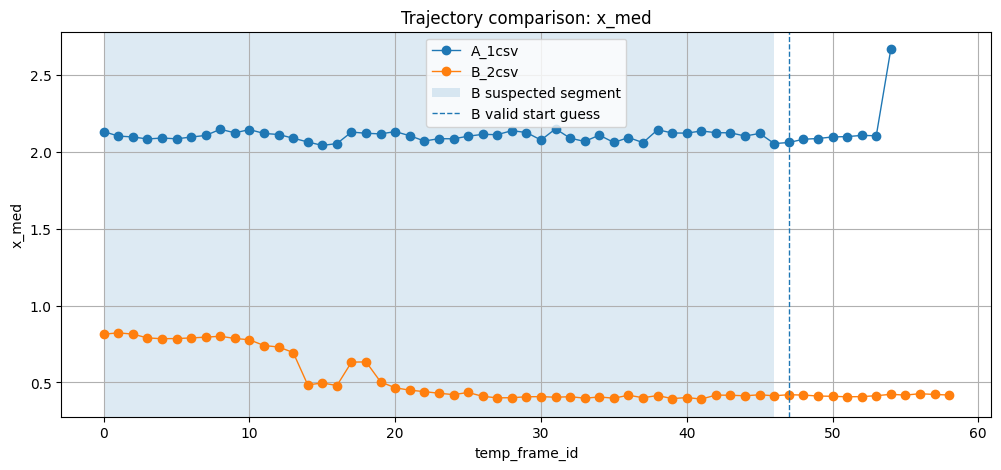

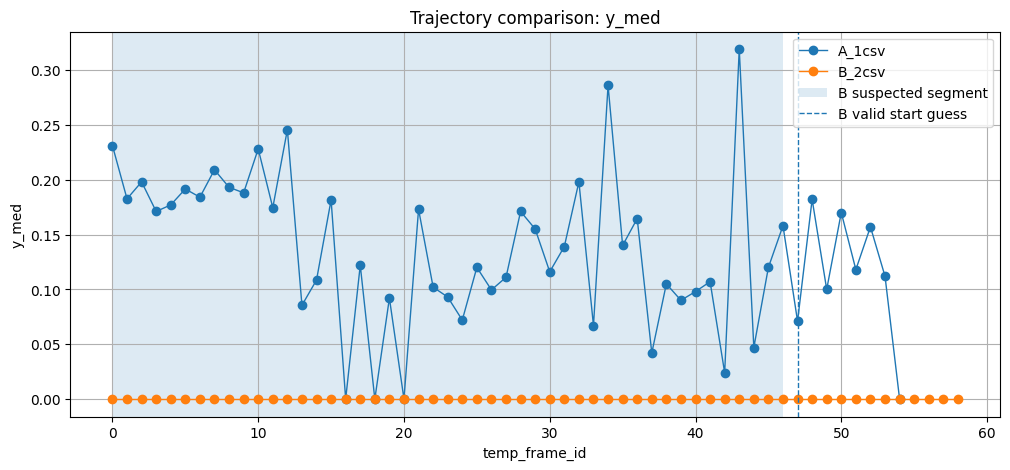

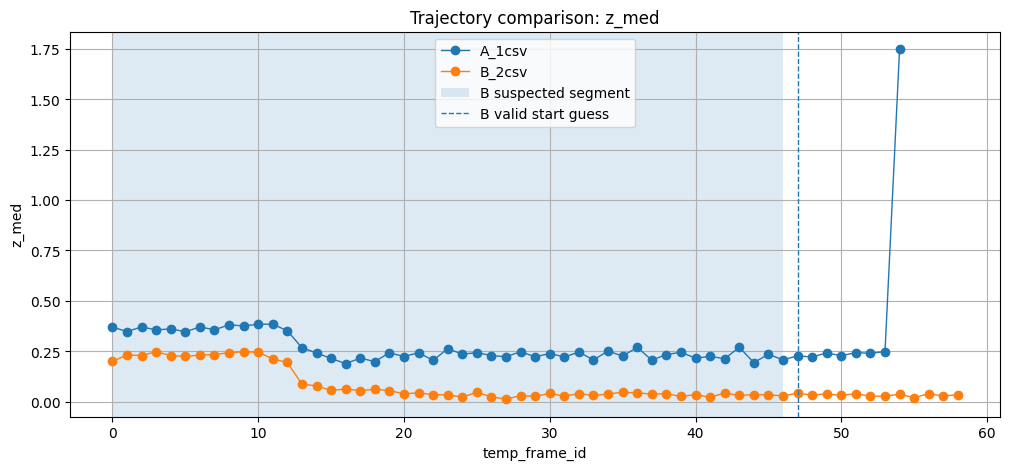

In [348]:
# Cell 13 - Plot trajectory median X/Y/Z per frame

def plot_trajectory(feature_name: str):
    plt.figure(figsize=(12, 5))

    plt.plot(fp_a["temp_frame_id"], fp_a[feature_name], marker="o", linewidth=1, label=LABEL_A)
    plt.plot(fp_b["temp_frame_id"], fp_b[feature_name], marker="o", linewidth=1, label=LABEL_B)

    plt.axvspan(B_SUSPECT_START, B_SUSPECT_END, alpha=0.15, label="B suspected segment")
    plt.axvline(B_VALID_START, linestyle="--", linewidth=1, label="B valid start guess")

    plt.title(f"Trajectory comparison: {feature_name}")
    plt.xlabel("temp_frame_id")
    plt.ylabel(feature_name)
    plt.legend()
    plt.grid(True)
    plt.show()

plot_trajectory("x_med")
plot_trajectory("y_med")
plot_trajectory("z_med")

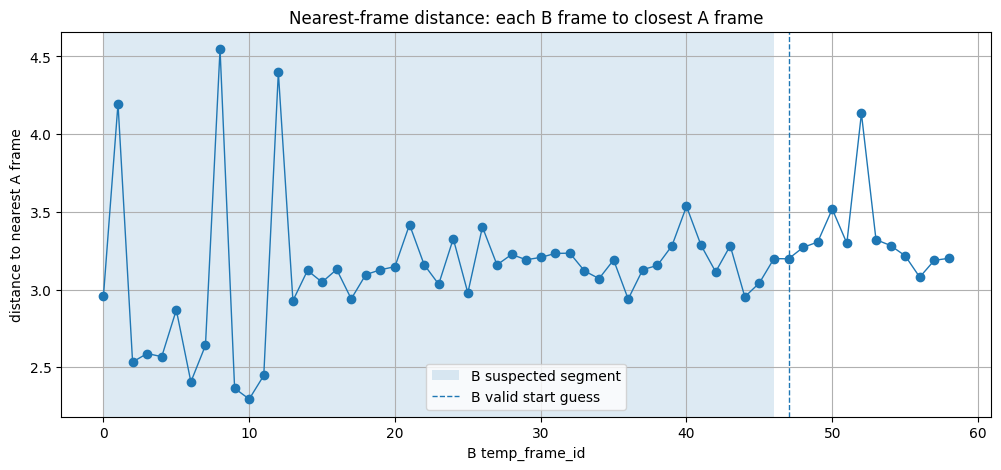

Distance summary by suspected vs valid segment:


,segment,count,mean,std,min,25%,50%,75%,max
0,B_suspect_0_46,47.0,3.110672,0.441931,2.295152,2.946338,3.126777,3.228797,4.546629
1,B_valid_47_end,12.0,3.334130,0.272383,3.079385,3.199934,3.276999,3.309178,4.132325


In [349]:
# Cell 14 - Plot nearest distance B to A

plt.figure(figsize=(12, 5))
plt.plot(nearest_df["B_frame"], nearest_df["distance"], marker="o", linewidth=1)

plt.axvspan(B_SUSPECT_START, B_SUSPECT_END, alpha=0.15, label="B suspected segment")
plt.axvline(B_VALID_START, linestyle="--", linewidth=1, label="B valid start guess")

plt.title("Nearest-frame distance: each B frame to closest A frame")
plt.xlabel("B temp_frame_id")
plt.ylabel("distance to nearest A frame")
plt.legend()
plt.grid(True)
plt.show()

print("Distance summary by suspected vs valid segment:")

nearest_df["segment"] = np.where(
    (nearest_df["B_frame"] >= B_SUSPECT_START) & (nearest_df["B_frame"] <= B_SUSPECT_END),
    "B_suspect_0_46",
    np.where(nearest_df["B_frame"] >= B_VALID_START, "B_valid_47_end", "other")
)

display(
    nearest_df.groupby("segment")["distance"]
    .describe()
    .reset_index()
)

In [350]:
# Cell 15 - Kesimpulan otomatis sederhana

timestamp_overlap_ratio_b = timestamp_overlap_summary["overlap_ratio_B"]
row_overlap_ratio_b = row_overlap_summary["identical_ratio_B"]

suspect_mean_distance = nearest_df.loc[
    (nearest_df["B_frame"] >= B_SUSPECT_START) &
    (nearest_df["B_frame"] <= B_SUSPECT_END),
    "distance"
].mean()

valid_mean_distance = nearest_df.loc[
    nearest_df["B_frame"] >= B_VALID_START,
    "distance"
].mean()

print("===== SIMPLE DIAGNOSTIC INTERPRETATION =====")

print(f"Timestamp overlap ratio vs B : {timestamp_overlap_ratio_b:.6f}")
print(f"Identical row overlap vs B   : {row_overlap_ratio_b:.6f}")
print(f"B suspect mean distance to A : {suspect_mean_distance:.6f}")
print(f"B valid mean distance to A   : {valid_mean_distance:.6f}")

print("\nInterpretation hints:")

if row_overlap_ratio_b > 0.01:
    print("- Ada identical row overlap yang cukup terlihat. Ini mengarah ke duplikasi literal antar file.")
else:
    print("- Identical row overlap tidak besar. Kalau visual masih mirip, kemungkinan mirip secara spasial, bukan duplikasi literal.")

if timestamp_overlap_ratio_b > 0.01:
    print("- Ada timestamp overlap yang cukup terlihat. Ini mencurigakan untuk inter-file overlap.")
else:
    print("- Timestamp overlap tidak besar. Residual masih mungkin terjadi jika timestamp berubah tetapi pola XYZ mirip.")

if pd.notna(suspect_mean_distance) and pd.notna(valid_mean_distance):
    if suspect_mean_distance < valid_mean_distance:
        print("- Segmen awal B lebih mirip ke A dibanding segmen valid B. Ini mendukung dugaan residual/spillover.")
    else:
        print("- Segmen awal B tidak lebih mirip ke A dibanding segmen valid B. Dugaan residual perlu dicek ulang secara visual.")
else:
    print("- Distance suspect/valid tidak lengkap. Cek apakah segment frame tersedia.")

===== SIMPLE DIAGNOSTIC INTERPRETATION =====
Timestamp overlap ratio vs B : 0.000000
Identical row overlap vs B   : 0.000000
B suspect mean distance to A : 3.110672
B valid mean distance to A   : 3.334130

Interpretation hints:
- Identical row overlap tidak besar. Kalau visual masih mirip, kemungkinan mirip secara spasial, bukan duplikasi literal.
- Timestamp overlap tidak besar. Residual masih mungkin terjadi jika timestamp berubah tetapi pola XYZ mirip.
- Segmen awal B lebih mirip ke A dibanding segmen valid B. Ini mendukung dugaan residual/spillover.
